In [1]:
import star, wind, cme, instrument,observation
from default_vals import bands
from astropy import units as un, constants as const
import matplotlib.pyplot as plt
import numpy as np

In [2]:
distance = 3.2 * un.pc
physical_size = 5*un.au
n_pix = 121
c, b = bands['H'].values()
h_band = [c - b/2, c + b/2]


/home/idavis/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0.5, 0.98, 'Photon flux from star at the earth')

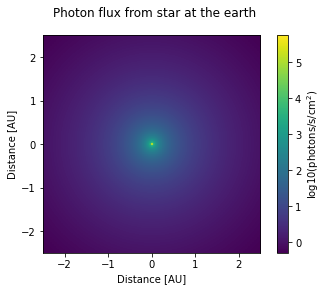

In [3]:
s = star.Star(temp=5080, radius=0.72*un.R_sun, distance=3.2*un.pc, linear_extent=physical_size, dim=n_pix, wavelength_range=h_band)
s.make_stellar_grids()
fig, ax = s.plot_stellar_flux()
fig.suptitle("Photon flux from star at the earth")

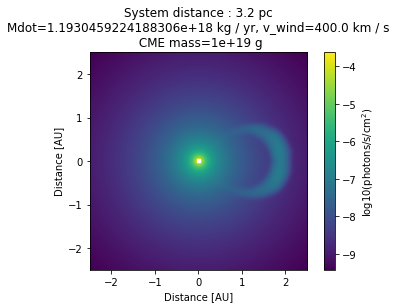

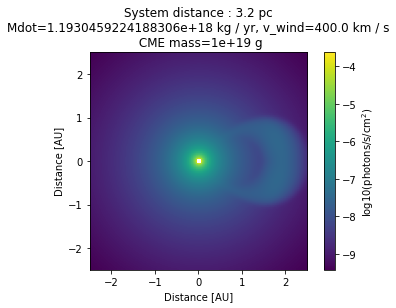

In [4]:
s.make_wind(Mdot=30*2e-14*const.M_sun/un.yr) # instantiates wind
s.make_cme(mass=1e19*un.g, horizontal_height_factor=2.3, dR_factor=0.2, smear=True, smear_sig=n_pix/90) #instantiates CME
s.particle_to_photon_flux()
fig, ax = s.plot_particle_fluxes()

s.make_cme(mass=1e19*un.g, horizontal_height_factor=0.1, dR_factor=0.5, smear=True, smear_sig=n_pix/90) #instantiates CME
s.particle_to_photon_flux()
fig, ax = s.plot_particle_fluxes()

## Imaging

### Observation instance and source construction

I've indicated the instrument is HWO, but default is that everything is normalised (the aperture remains 8m, but the focal length is 1m and the reference wavelength is 1m so that spatial resolution elements are in fractions of the aperture diameter)

/home/idavis/Iveys_ToolBox/cme_imaging/observation.py:32: UserWarning: Observation centre wavelength (1630.0 nm) does not match instrument centre wavelength (1.0 m)
  warnings.warn(f"Observation centre wavelength ({self.centre_wave}) does not match instrument centre wavelength ({instrument.band.centre_wave})")
/home/idavis/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0.5, 1.0, 'Mass = 1e+25 g')

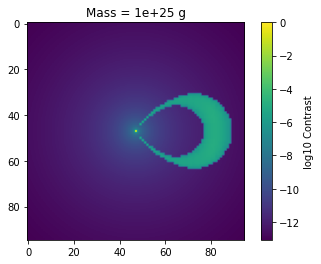

In [13]:
hwo = instrument.Instrument('H', name='HWO', res_sampling=3)
obs = observation.Observation(hwo, band = 'H', source_dim = 95)
obs.add_star()
obs.star.make_wind()
obs.star.make_cme(horizontal_height_factor=1., dR_factor=0.3, mass=1e25*un.g)
obs.make_obs_source()

im = plt.imshow(np.log10(obs.source/obs.source.max()))
cbar = plt.colorbar(im)
cbar.set_label("log10 Contrast")
plt.title(f"Mass = {obs.star.cme.mass}")

### Source to image

Actual imaging is a bit computational expensive for an extended source---each spatial pixel needs to be evaluated across the entire focal plane independently for an incoherent source.

In [14]:
obs.conduct_observation()

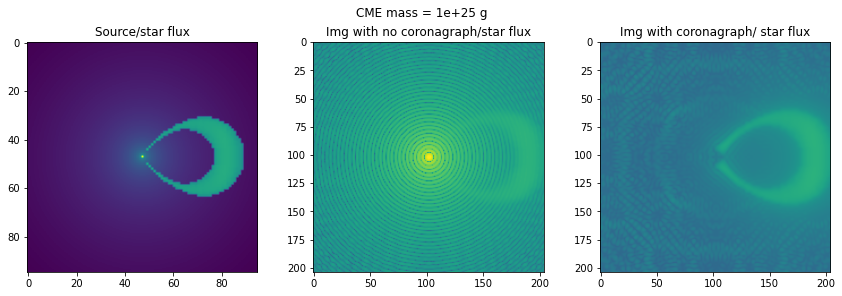

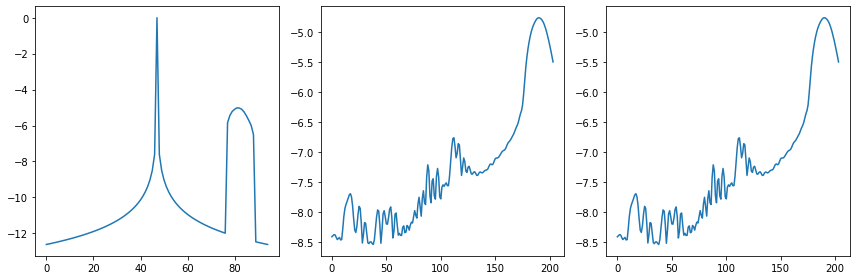

In [18]:
from hcipy import Wavefront

star_wf = Wavefront(obs.instrument.ap * np.nanmax(obs.source), wavelength=obs.instrument.reference_wavelength.to('m').value)
star_img = obs.instrument.prop(star_wf).intensity.reshape(obs.instrument.focal_grid.shape)
lyot_plane = obs.instrument.coronagraph(star_wf)
post_lyot_mask = obs.instrument.lyot_stop(lyot_plane)
star_cor_img = obs.instrument.prop(post_lyot_mask).intensity.reshape(obs.instrument.focal_grid.shape)

img = obs.instrument.img[0]
img_ref = obs.instrument.img_ref[0]

fig, axs = plt.subplots(1,3)
im0 = axs[0].imshow(np.log10(obs.source/obs.source.max()))
vmin, vmax = im0.get_clim()
im1 = axs[1].imshow(np.log10(img_ref/img_ref.max()), vmin = vmin, vmax=vmax)
im2 = axs[2].imshow(np.log10((img/img_ref.max())), vmin = vmin, vmax=vmax)

fig.suptitle(f"CME mass = {obs.star.cme.mass}")
axs[0].set_title("Source/star flux")
axs[1].set_title("Img with no coronagraph/star flux")
axs[2].set_title("Img with coronagraph/ star flux")

fig.set_figwidth(12)
fig.set_figheight(4)
fig.tight_layout()
    

fig, axs = plt.subplots(1,3)
center = int(obs.instrument.focal_grid.shape[0]/2)
axs[0].plot(np.log10(obs.source/obs.source.max())[int(obs.star.grid_cme_photons.shape[0]/2),:])
axs[1].plot(np.log10(np.abs(img/img_ref.max()))[center,:])
axs[2].plot(np.log10(np.abs(img)/img_ref.max())[center,:])


fig.set_figwidth(12)
fig.set_figheight(4)
fig.tight_layout()
    
